In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Input
from tensorflow.keras.models import Model
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

# Paths
image_folder = "D:/Water Bodies Dataset/Images/"
mask_folder = "D:/Water Bodies Dataset/Masks"
img_size = (128, 128)  # Resize all images to this shape for the model

def load_data(folder, size):
    data = []
    for filename in sorted(os.listdir(folder)):
        if filename.endswith(".jpg"):
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path)
            img = cv2.resize(img, size)
            img = img / 255.0  # Normalize
            data.append(img)
    return np.array(data)

# Load images and masks
images = load_data(image_folder, img_size)
masks = load_data(mask_folder, img_size)

# Ensure masks are binary
masks = (masks[..., 0] > 0.5).astype(np.float32)
masks = np.expand_dims(masks, axis=-1)

# Split the dataset
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)

In [4]:
# Build U-Net model
def unet_model(input_shape):
    inputs = Input(shape=input_shape)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # Bottleneck
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)

    # Decoder
    u1 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c3)
    u1 = concatenate([u1, c2])
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(u1)
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(c4)

    u2 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c4)
    u2 = concatenate([u2, c1])
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(u2)
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(c5)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c5)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model


Epoch 1/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 2190s 8s/step - accuracy: 0.7375 - loss: 0.5346 - val_accuracy: 0.7753 - val_loss: 0.4660
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 2184s 8s/step - accuracy: 0.7726 - loss: 0.4678 - val_accuracy: 0.7851 - val_loss: 0.4511
Epoch 3/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 2249s 8s/step - accuracy: 0.7933 - loss: 0.4532 - val_accuracy: 0.8463 - val_loss: 0.3662
Epoch 4/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 2190s 8s/step - accuracy: 0.8383 - loss: 0.3859 - val_accuracy: 0.8511 - val_loss: 0.3498
Epoch 5/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 2192s 8s/step - accuracy: 0.8551 - loss: 0.3525 - val_accuracy: 0.8474 - val_loss: 0.3715
Epoch 6/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 2190s 8s/step - accuracy: 0.8612 - loss: 0.3354 - val_accuracy: 0.8673 - val_loss: 0.3156
Epoch 7/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 2241s 8s/step - accuracy: 0.8672 - loss: 0.3270 - val_accuracy: 0.8814 - val_loss: 0.2941
Epoch 8/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 2240s 8s/step - accuracy: 0.8738 - loss: 0.3081 - 

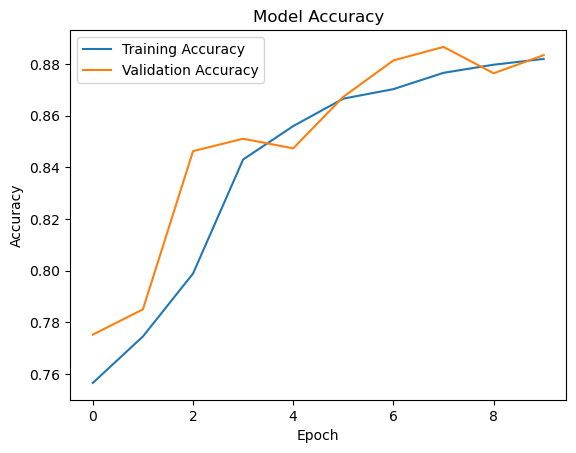

In [5]:
# Compile the model
model = unet_model(input_shape=(img_size[0], img_size[1], 3))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=8)

# Save the model
model.save("unet_water_body_detection1.h5")

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
# Load the saved model
model = tf.keras.models.load_model("unet_water_body_detection1.h5")

# Make predictions on validation images
predictions = model.predict(X_val)

# Threshold the predicted masks
predicted_masks = (predictions > 0.5).astype(np.uint8)

# Plot a few predictions alongside original images and ground truth masks
for i in range(5):  # Displaying 5 random samples
    plt.figure(figsize=(15, 5))

    # Original validation image
    plt.subplot(1, 3, 1)
    plt.imshow(X_val[i])
    plt.title("Original Image")
    plt.axis('off')

    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(y_val[i].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')

    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_masks[i].squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.show()


In [ ]:
model.summary()

### HyperParameter Tuning ###

17/17 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step


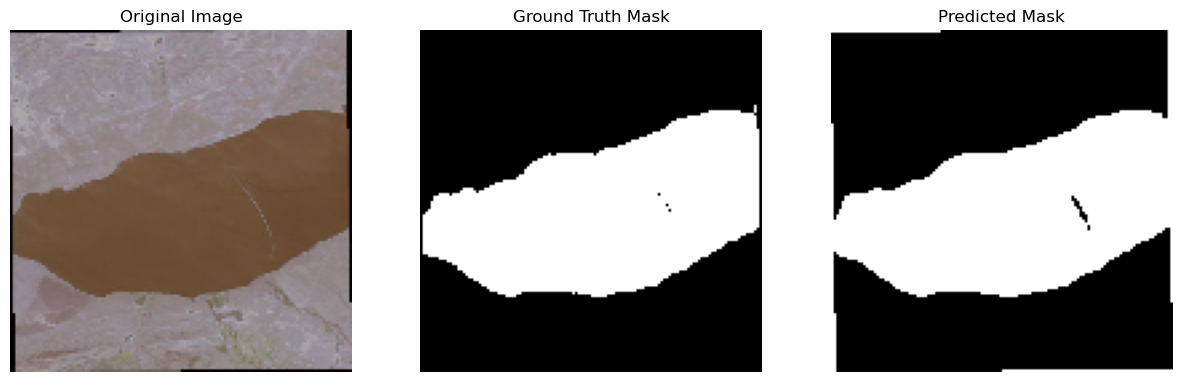

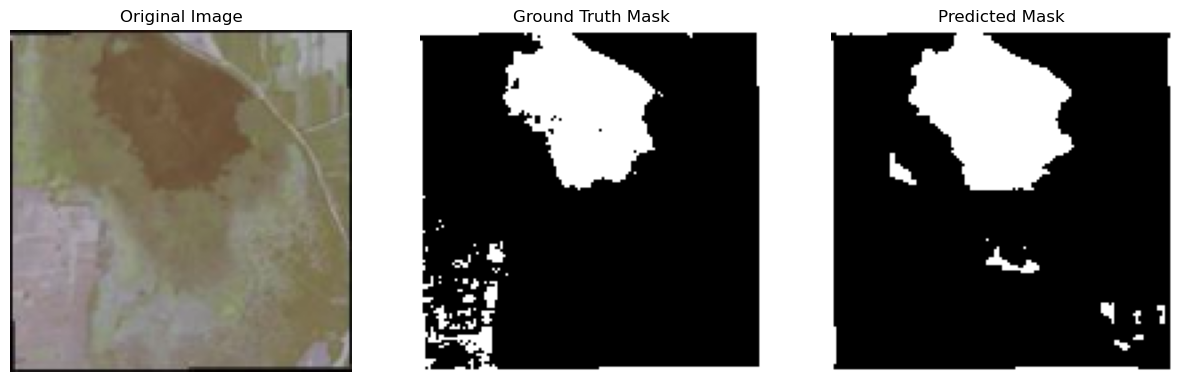

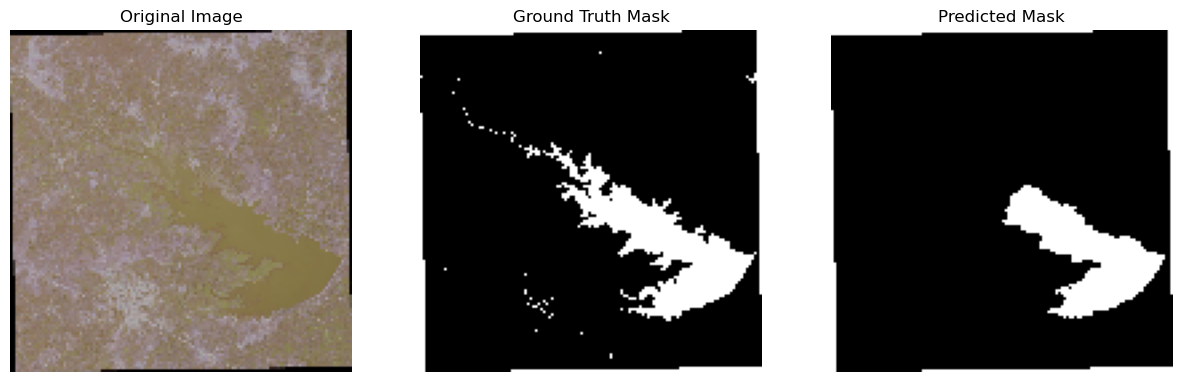

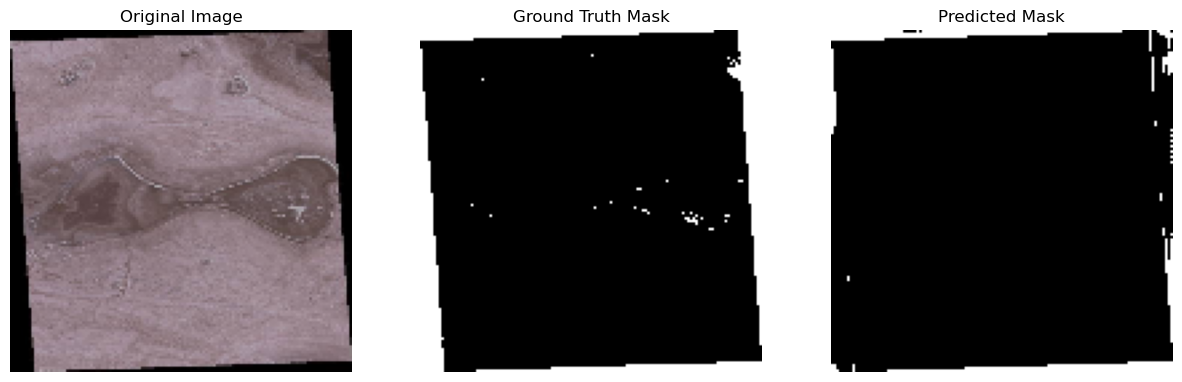

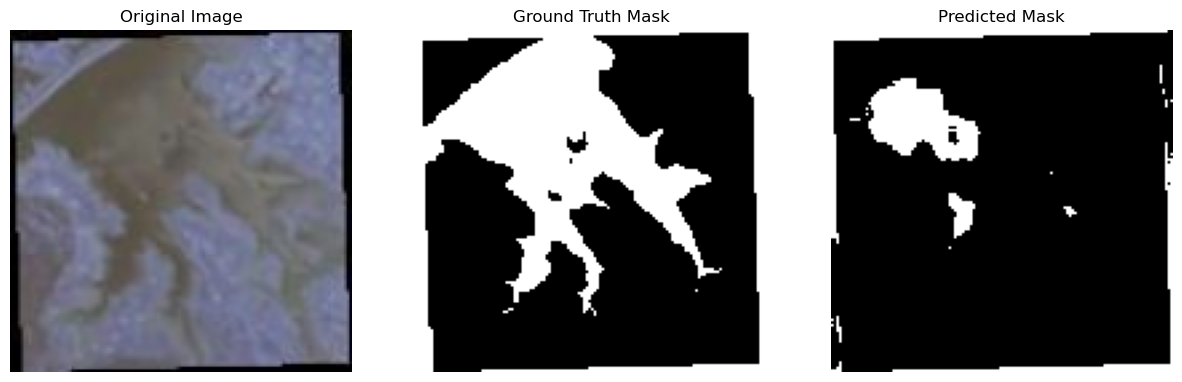

In [10]:
import random

# Load the saved model
model = tf.keras.models.load_model("unet_water_body_detection1.h5")

# Make predictions on validation images
predictions = model.predict(X_val)

# Threshold the predicted masks
predicted_masks = (predictions > 0.5).astype(np.uint8)

# Select 5 random indices
random_indices = random.sample(range(len(X_val)), 5)

# Plot random predictions alongside original images and ground truth masks
for i, idx in enumerate(random_indices):
    plt.figure(figsize=(15, 5))

    # Original validation image
    plt.subplot(1, 3, 1)
    plt.imshow(X_val[idx])
    plt.title("Original Image")
    plt.axis('off')

    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(y_val[idx].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')

    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_masks[idx].squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import cv2
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

# Load and preprocess dataset
def load_data(image_folder, mask_folder, img_size=(256, 256)):
    images, masks = [], []
    image_files = sorted(os.listdir(image_folder))
    mask_files = sorted(os.listdir(mask_folder))
    
    for img_file, mask_file in zip(image_files, mask_files):
        img = load_img(os.path.join(image_folder, img_file), target_size=img_size)
        mask = load_img(os.path.join(mask_folder, mask_file), target_size=img_size, color_mode='grayscale')
        
        images.append(img_to_array(img) / 255.0)
        masks.append(img_to_array(mask) / 255.0)
    
    return np.array(images), np.array(masks)

# Define U-Net model
def unet_model(input_shape=(256, 256, 3)):
    inputs = tf.keras.layers.Input(input_shape)
    
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)
    
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
    
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
    
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)
    
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)
    
    u6 = tf.keras.layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)
    
    u7 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)
    
    u8 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)
    
    u9 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)
    
    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)
    
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Load dataset
image_folder = "D:/Water Bodies Dataset/Images/"
mask_folder = "D:/Water Bodies Dataset/Masks/"
X, y = load_data(image_folder, mask_folder)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = unet_model()
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=16)

# Save the trained model
model.save("unet_water_body_detection.h5")

# Evaluate model
predictions = model.predict(X_val)
predicted_masks = (predictions > 0.5).astype(np.uint8)

# Display random samples
random_indices = random.sample(range(len(X_val)), 5)
for i, idx in enumerate(random_indices):
    print(f"File Name: {os.listdir('path_to_images')[idx]}")
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(X_val[idx])
    plt.title("Original Image")
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(y_val[idx].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_masks[idx].squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')
    plt.show()


Epoch 1/20


### There were some images, whose masks were completely blacked out, which we deleted.

In [5]:
import numpy as np
import os
import cv2
mask_folder = "D:/Water Bodies Dataset/Masks/"
mask_files = sorted(os.listdir(mask_folder))
white_mask_count = 0

for mask_file in mask_files:
    mask = cv2.imread(os.path.join(mask_folder, mask_file), cv2.IMREAD_GRAYSCALE)
    if np.all(mask == 255):  # Check if the entire mask is white
        print(f"Completely white mask: {mask_file}")
        white_mask_count += 1

print(f"Total completely white masks: {white_mask_count}")


Completely white mask: water_body_1023.jpg
Completely white mask: water_body_1061.jpg
Completely white mask: water_body_1225.jpg
Completely white mask: water_body_1226.jpg
Completely white mask: water_body_1232.jpg
Completely white mask: water_body_1244.jpg
Completely white mask: water_body_1333.jpg
Completely white mask: water_body_1342.jpg
Completely white mask: water_body_1364.jpg
Completely white mask: water_body_1370.jpg
Completely white mask: water_body_1371.jpg
Completely white mask: water_body_1397.jpg
Completely white mask: water_body_15.jpg
Completely white mask: water_body_1552.jpg
Completely white mask: water_body_1553.jpg
Completely white mask: water_body_1562.jpg
Completely white mask: water_body_1606.jpg
Completely white mask: water_body_1607.jpg
Completely white mask: water_body_1616.jpg
Completely white mask: water_body_1619.jpg
Completely white mask: water_body_1621.jpg
Completely white mask: water_body_1659.jpg
Completely white mask: water_body_1661.jpg
Completely wh

In [6]:
import os
import cv2
import numpy as np

# Define the paths for images and masks
image_folder = "D:/Water Bodies Dataset/Images/"
mask_folder = "D:/Water Bodies Dataset/Masks/"

# Get all mask files (assuming masks are in .jpg format)
mask_files = sorted(os.listdir(mask_folder))

# Initialize counter for white masks
white_mask_count = 0

# Loop through all mask files
for mask_file in mask_files:
    mask_path = os.path.join(mask_folder, mask_file)
    
    # Load the mask as a grayscale image
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Check if the mask is completely white
    if mask is not None and np.all(mask == 255):
        print(f"Completely white mask: {mask_file}")
        white_mask_count += 1
        
        # Construct the corresponding image file path
        image_file = mask_file.replace('.jpg', '.jpg')  # Assuming images are in .jpg format
        image_path = os.path.join(image_folder, image_file)
        
        # Delete both the image and mask if both exist
        if os.path.exists(image_path):
            os.remove(image_path)
            print(f"Deleted image: {image_file}")
        
        os.remove(mask_path)
        print(f"Deleted mask: {mask_file}")

# Print the total number of white masks
print(f"Total completely white masks deleted: {white_mask_count}")


Completely white mask: water_body_1023.jpg
Deleted image: water_body_1023.jpg
Deleted mask: water_body_1023.jpg
Completely white mask: water_body_1061.jpg
Deleted image: water_body_1061.jpg
Deleted mask: water_body_1061.jpg
Completely white mask: water_body_1225.jpg
Deleted image: water_body_1225.jpg
Deleted mask: water_body_1225.jpg
Completely white mask: water_body_1226.jpg
Deleted image: water_body_1226.jpg
Deleted mask: water_body_1226.jpg
Completely white mask: water_body_1232.jpg
Deleted image: water_body_1232.jpg
Deleted mask: water_body_1232.jpg
Completely white mask: water_body_1244.jpg
Deleted image: water_body_1244.jpg
Deleted mask: water_body_1244.jpg
Completely white mask: water_body_1333.jpg
Deleted image: water_body_1333.jpg
Deleted mask: water_body_1333.jpg
Completely white mask: water_body_1342.jpg
Deleted image: water_body_1342.jpg
Deleted mask: water_body_1342.jpg
Completely white mask: water_body_1364.jpg
Deleted image: water_body_1364.jpg
Deleted mask: water_body_1